In [2]:
# Step 1: Mount Google Drive and Load Dataset
from google.colab import drive
import pandas as pd
import numpy as np

# Mount Google Drive
drive.mount('/content/drive')
print("✓ Google Drive mounted successfully!")

# Load the Heart Disease dataset
print("\n" + "=" * 60)
print("LOADING DATASET")
print("=" * 60)

df = pd.read_csv('/content/drive/MyDrive/ML&&AI/Lab 3/dataset/heart-disease.csv')

# Display basic information
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(df['target'].value_counts())
print(f"\nClass 0 (No disease): {(df['target']==0).sum()} ({(df['target']==0).sum()/len(df)*100:.1f}%)")
print(f"Class 1 (Has disease): {(df['target']==1).sum()} ({(df['target']==1).sum()/len(df)*100:.1f}%)")

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(list(df.columns))

print("\n✓ Dataset loaded successfully!")

Mounted at /content/drive
✓ Google Drive mounted successfully!

LOADING DATASET

Dataset Shape: (303, 14)
Number of Rows: 303
Number of Columns: 14

FIRST 5 ROWS
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non

In [3]:
# Step 2: Data Preprocessing for KNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("DATA PREPROCESSING FOR KNN")
print("=" * 60)

# Check for duplicates
print("\n[1/5] Checking for duplicates...")
duplicates = df.duplicated().sum()
print(f"  Duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"  ✓ Removed {duplicates} duplicates")
    print(f"  Dataset shape after: {df.shape}")

# Separate features and target
print("\n[2/5] Separating features and target...")
X = df.drop('target', axis=1)
y = df['target']
print(f"  Features shape: {X.shape}")
print(f"  Target shape: {y.shape}")
print(f"  Feature columns: {list(X.columns)}")

# Split data: 70% train, 15% validation, 15% test
print("\n[3/5] Splitting data (70% train, 15% val, 15% test)...")
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

# Check class distribution in splits
print("\n[4/5] Verifying class distribution in splits...")
print(f"  Training - Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()}")
print(f"  Validation - Class 0: {(y_val==0).sum()}, Class 1: {(y_val==1).sum()}")
print(f"  Test - Class 0: {(y_test==0).sum()}, Class 1: {(y_test==1).sum()}")

# Feature Scaling (CRITICAL for KNN!)
print("\n[5/5] Scaling features (CRITICAL for KNN)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"  ✓ Features standardized using StandardScaler")
print(f"  Example - 'age' feature:")
print(f"    Before scaling - Mean: {X_train.iloc[:, 0].mean():.2f}, Std: {X_train.iloc[:, 0].std():.2f}")
print(f"    After scaling  - Mean: {X_train_scaled[:, 0].mean():.4f}, Std: {X_train_scaled[:, 0].std():.4f}")

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETED!")
print("=" * 60)
print("\n✓ Data is ready for KNN training")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")
print("\nNote: Feature scaling is essential for KNN as it's a distance-based algorithm!")

DATA PREPROCESSING FOR KNN

[1/5] Checking for duplicates...
  Duplicate rows: 1
  ✓ Removed 1 duplicates
  Dataset shape after: (302, 14)

[2/5] Separating features and target...
  Features shape: (302, 13)
  Target shape: (302,)
  Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

[3/5] Splitting data (70% train, 15% val, 15% test)...
  Training set: 211 samples (69.9%)
  Validation set: 45 samples (14.9%)
  Test set: 46 samples (15.2%)

[4/5] Verifying class distribution in splits...
  Training - Class 0: 96, Class 1: 115
  Validation - Class 0: 21, Class 1: 24
  Test - Class 0: 21, Class 1: 25

[5/5] Scaling features (CRITICAL for KNN)...
  ✓ Features standardized using StandardScaler
  Example - 'age' feature:
    Before scaling - Mean: 54.32, Std: 9.28
    After scaling  - Mean: 0.0000, Std: 1.0000

PREPROCESSING COMPLETED!

✓ Data is ready for KNN training
  Train: (211, 13)
  Val:   (45, 13)
  Test:

In [4]:
# Step 3: Train Baseline KNN Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

print("=" * 60)
print("TRAINING BASELINE KNN MODEL")
print("=" * 60)

# Train baseline KNN with k=5 (default)
print("\n[1/3] Training KNN with default parameters...")
print("  Parameters: n_neighbors=5, weights='uniform', metric='minkowski'")

start_time = time.time()
knn_baseline = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')
knn_baseline.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"  ✓ Training completed in {training_time:.4f} seconds")

# Predict on validation set
print("\n[2/3] Making predictions on validation set...")
y_val_pred = knn_baseline.predict(X_val_scaled)

# Calculate metrics
print("\n[3/3] Calculating evaluation metrics...")
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("\n" + "=" * 60)
print("BASELINE KNN PERFORMANCE (Validation Set)")
print("=" * 60)
print(f"\nAccuracy:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Precision: {val_precision:.4f} ({val_precision*100:.2f}%)")
print(f"Recall:    {val_recall:.4f} ({val_recall*100:.2f}%)")
print(f"F1-Score:  {val_f1:.4f} ({val_f1*100:.2f}%)")

print("\n" + "-" * 60)
print("Detailed Classification Report:")
print("-" * 60)
print(classification_report(y_val, y_val_pred,
                          target_names=['No Disease (0)', 'Has Disease (1)'],
                          digits=4))

print("\n" + "=" * 60)
print("BASELINE KNN SUMMARY")
print("=" * 60)
print(f"Model: KNeighborsClassifier(n_neighbors=5)")
print(f"Training time: {training_time:.4f} seconds")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print("\n✓ Baseline model trained successfully!")
print("  Next: Finding optimal k using Elbow Method")

TRAINING BASELINE KNN MODEL

[1/3] Training KNN with default parameters...
  Parameters: n_neighbors=5, weights='uniform', metric='minkowski'
  ✓ Training completed in 0.0049 seconds

[2/3] Making predictions on validation set...

[3/3] Calculating evaluation metrics...

BASELINE KNN PERFORMANCE (Validation Set)

Accuracy:  0.7333 (73.33%)
Precision: 0.7000 (70.00%)
Recall:    0.8750 (87.50%)
F1-Score:  0.7778 (77.78%)

------------------------------------------------------------
Detailed Classification Report:
------------------------------------------------------------
                 precision    recall  f1-score   support

 No Disease (0)     0.8000    0.5714    0.6667        21
Has Disease (1)     0.7000    0.8750    0.7778        24

       accuracy                         0.7333        45
      macro avg     0.7500    0.7232    0.7222        45
   weighted avg     0.7467    0.7333    0.7259        45


BASELINE KNN SUMMARY
Model: KNeighborsClassifier(n_neighbors=5)
Training tim

ELBOW METHOD - FINDING OPTIMAL K

[1/2] Testing different k values (1 to 30)...
  This may take a moment...

  k= 1 -> Train Acc: 1.0000, Val Acc: 0.6444, Error: 0.3556
  k= 5 -> Train Acc: 0.8815, Val Acc: 0.7333, Error: 0.2667
  k=10 -> Train Acc: 0.8483, Val Acc: 0.7778, Error: 0.2222
  k=15 -> Train Acc: 0.8483, Val Acc: 0.7778, Error: 0.2222
  k=20 -> Train Acc: 0.8246, Val Acc: 0.7778, Error: 0.2222
  k=25 -> Train Acc: 0.8246, Val Acc: 0.7778, Error: 0.2222
  k=30 -> Train Acc: 0.8341, Val Acc: 0.7778, Error: 0.2222

[2/2] Analysis completed!

OPTIMAL K VALUE
  Optimal k: 11
  Validation Accuracy: 0.8000 (80.00%)
  Error Rate: 0.2000 (20.00%)

GENERATING ELBOW METHOD PLOTS
  ✓ Elbow Method plots saved as 'knn_elbow_method.png'


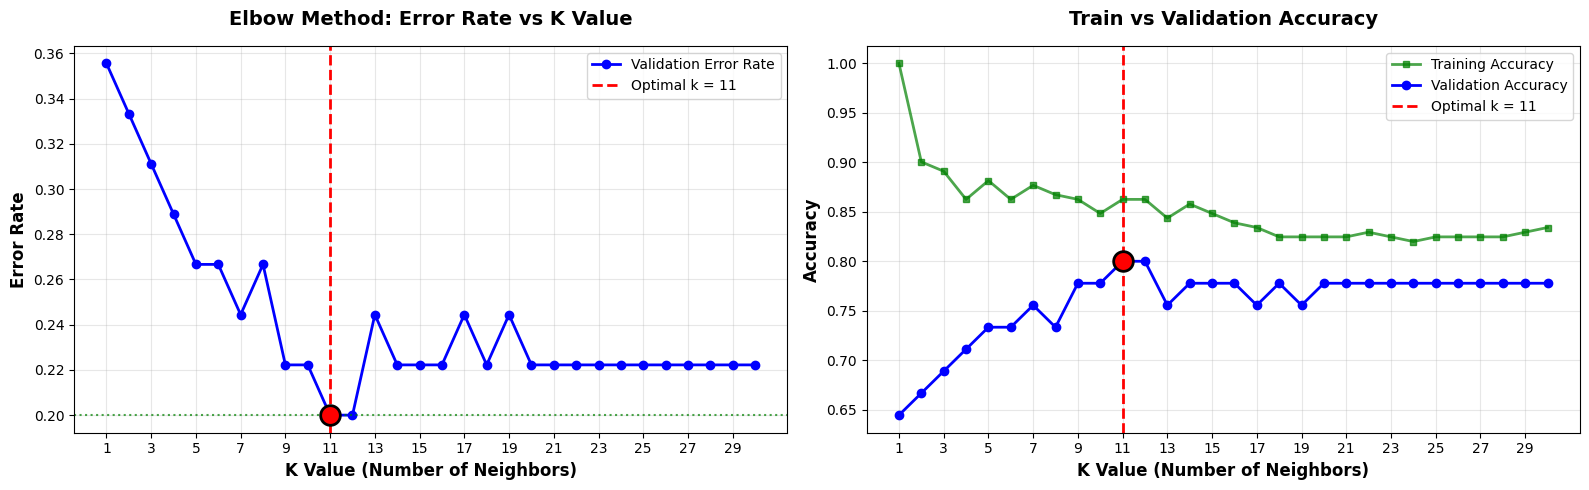


ELBOW METHOD COMPLETED!

✓ Optimal k value found: 11
  Next: Hyperparameter tuning with GridSearchCV


In [5]:
# Step 4: Elbow Method - Find Optimal K
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("ELBOW METHOD - FINDING OPTIMAL K")
print("=" * 60)

# Test different k values
k_range = range(1, 31)  # Test k from 1 to 30
train_scores = []
val_scores = []
error_rates = []

print("\n[1/2] Testing different k values (1 to 30)...")
print("  This may take a moment...\n")

for k in k_range:
    # Train KNN with current k
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='minkowski')
    knn.fit(X_train_scaled, y_train)

    # Calculate accuracy on train and validation sets
    train_pred = knn.predict(X_train_scaled)
    val_pred = knn.predict(X_val_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    train_scores.append(train_acc)
    val_scores.append(val_acc)
    error_rates.append(1 - val_acc)

    if k % 5 == 0 or k == 1:
        print(f"  k={k:2d} -> Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Error: {1-val_acc:.4f}")

# Find optimal k (highest validation accuracy)
optimal_k = k_range[np.argmax(val_scores)]
optimal_accuracy = max(val_scores)

print("\n[2/2] Analysis completed!")
print("\n" + "=" * 60)
print("OPTIMAL K VALUE")
print("=" * 60)
print(f"  Optimal k: {optimal_k}")
print(f"  Validation Accuracy: {optimal_accuracy:.4f} ({optimal_accuracy*100:.2f}%)")
print(f"  Error Rate: {1-optimal_accuracy:.4f} ({(1-optimal_accuracy)*100:.2f}%)")

# Create Elbow Method plots
print("\n" + "=" * 60)
print("GENERATING ELBOW METHOD PLOTS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Error Rate vs K
axes[0].plot(k_range, error_rates, 'b-o', linewidth=2, markersize=6, label='Validation Error Rate')
axes[0].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
axes[0].axhline(y=1-optimal_accuracy, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].scatter([optimal_k], [1-optimal_accuracy], color='red', s=200, zorder=5,
                edgecolors='black', linewidth=2)
axes[0].set_xlabel('K Value (Number of Neighbors)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error Rate', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method: Error Rate vs K Value', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 31, 2))

# Plot 2: Accuracy vs K (Train and Validation)
axes[1].plot(k_range, train_scores, 'g-s', linewidth=2, markersize=5,
             label='Training Accuracy', alpha=0.7)
axes[1].plot(k_range, val_scores, 'b-o', linewidth=2, markersize=6,
             label='Validation Accuracy')
axes[1].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
                label=f'Optimal k = {optimal_k}')
axes[1].scatter([optimal_k], [optimal_accuracy], color='red', s=200, zorder=5,
                edgecolors='black', linewidth=2)
axes[1].set_xlabel('K Value (Number of Neighbors)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Train vs Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 31, 2))

plt.tight_layout()
plt.savefig('knn_elbow_method.png', dpi=300, bbox_inches='tight')
print("  ✓ Elbow Method plots saved as 'knn_elbow_method.png'")
plt.show()

print("\n" + "=" * 60)
print("ELBOW METHOD COMPLETED!")
print("=" * 60)
print(f"\n✓ Optimal k value found: {optimal_k}")
print(f"  Next: Hyperparameter tuning with GridSearchCV")

In [6]:
# Step 5: Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("=" * 60)

# Define parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

print("\nParameter Grid:")
print("-" * 60)
print(f"  n_neighbors (k): {param_grid['n_neighbors']}")
print(f"  weights: {param_grid['weights']}")
print(f"  metric: {param_grid['metric']}")

total_combinations = len(param_grid['n_neighbors']) * len(param_grid['weights']) * len(param_grid['metric'])
print(f"\nTotal combinations: {total_combinations}")

# Setup GridSearchCV
print("\n[1/3] Setting up GridSearchCV...")
knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all CPU cores
    verbose=1,
    return_train_score=True
)

print("  ✓ Configuration:")
print(f"    - Cross-validation: 5-fold")
print(f"    - Scoring metric: accuracy")
print(f"    - Parallel jobs: all cores")

# Run Grid Search
print("\n[2/3] Running Grid Search...")
print("      Please wait... ⏳")
print("-" * 60)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
tuning_time = time.time() - start_time

print("-" * 60)
print(f"  ✓ Grid Search completed in {tuning_time:.2f} seconds")

# Extract best parameters
print("\n[3/3] Extracting results...")
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 60)
for param, value in best_params.items():
    print(f"  {param:15s}: {value}")

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"Best CV Score (Training): {best_score:.4f} ({best_score*100:.2f}%)")

# Evaluate on validation set
print("\n" + "=" * 60)
print("VALIDATION SET PERFORMANCE")
print("=" * 60)

y_val_pred_tuned = best_model.predict(X_val_scaled)
val_accuracy_tuned = accuracy_score(y_val, y_val_pred_tuned)
val_precision_tuned = precision_score(y_val, y_val_pred_tuned)
val_recall_tuned = recall_score(y_val, y_val_pred_tuned)
val_f1_tuned = f1_score(y_val, y_val_pred_tuned)

print(f"\nAccuracy:  {val_accuracy_tuned:.4f} ({val_accuracy_tuned*100:.2f}%)")
print(f"Precision: {val_precision_tuned:.4f} ({val_precision_tuned*100:.2f}%)")
print(f"Recall:    {val_recall_tuned:.4f} ({val_recall_tuned*100:.2f}%)")
print(f"F1-Score:  {val_f1_tuned:.4f} ({val_f1_tuned*100:.2f}%)")

print("\n" + "-" * 60)
print("Classification Report:")
print("-" * 60)
print(classification_report(y_val, y_val_pred_tuned,
                          target_names=['No Disease (0)', 'Has Disease (1)']))

# Comparison
print("\n" + "=" * 60)
print("COMPARISON: BASELINE vs TUNED MODEL")
print("=" * 60)
print(f"Baseline (k=5):    {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Tuned Model:       {val_accuracy_tuned:.4f} ({val_accuracy_tuned*100:.2f}%)")
improvement = (val_accuracy_tuned - val_accuracy) * 100
print(f"Improvement:       {improvement:+.2f}%")

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING COMPLETED!")
print("=" * 60)

HYPERPARAMETER TUNING WITH GRIDSEARCHCV

Parameter Grid:
------------------------------------------------------------
  n_neighbors (k): [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan', 'minkowski']

Total combinations: 60

[1/3] Setting up GridSearchCV...
  ✓ Configuration:
    - Cross-validation: 5-fold
    - Scoring metric: accuracy
    - Parallel jobs: all cores

[2/3] Running Grid Search...
      Please wait... ⏳
------------------------------------------------------------
Fitting 5 folds for each of 60 candidates, totalling 300 fits
------------------------------------------------------------
  ✓ Grid Search completed in 6.83 seconds

[3/3] Extracting results...

BEST HYPERPARAMETERS FOUND
  metric         : manhattan
  n_neighbors    : 5
  weights        : uniform

CROSS-VALIDATION RESULTS
Best CV Score (Training): 0.8487 (84.87%)

VALIDATION SET PERFORMANCE

Accuracy:  0.7111 (71.11%)
Precision: 0.6774 (67.74%)
Recall:

In [7]:
# Step 6: Final Evaluation on Test Set
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

print("=" * 60)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Use the model with k=11 (from Elbow Method - best validation performance)
print("\nUsing: KNN with k=11 (from Elbow Method)")
print("-" * 60)

# Train final model with optimal k
final_knn = KNeighborsClassifier(n_neighbors=11, weights='uniform', metric='minkowski')
final_knn.fit(X_train_scaled, y_train)

# Predictions on test set
print("\n[1/5] Making predictions on test set...")
y_test_pred = final_knn.predict(X_test_scaled)
y_test_proba = final_knn.predict_proba(X_test_scaled)[:, 1]

# Calculate all metrics
print("\n[2/5] Calculating evaluation metrics...")
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE METRICS")
print("=" * 60)
print(f"\n{'Metric':<15} {'Score':<10} {'Percentage'}")
print("-" * 60)
print(f"{'Accuracy':<15} {test_accuracy:.4f}    {test_accuracy*100:.2f}%")
print(f"{'Precision':<15} {test_precision:.4f}    {test_precision*100:.2f}%")
print(f"{'Recall':<15} {test_recall:.4f}    {test_recall*100:.2f}%")
print(f"{'F1-Score':<15} {test_f1:.4f}    {test_f1*100:.2f}%")
print(f"{'AUC-ROC':<15} {test_auc:.4f}    {test_auc*100:.2f}%")

print("\n" + "-" * 60)
print("Detailed Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_test_pred,
                          target_names=['No Disease (0)', 'Has Disease (1)'],
                          digits=4))

# Confusion Matrix
print("\n[3/5] Generating Confusion Matrix...")
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

# Sample predictions
print("\n[4/5] Sample predictions (first 10 test samples)...")
print("-" * 80)
print(f"{'Index':<8} {'Actual':<10} {'Predicted':<12} {'Prob(No)':<12} {'Prob(Yes)':<12} {'Result'}")
print("-" * 80)

for i in range(min(10, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_test_pred[i]
    prob_0 = final_knn.predict_proba(X_test_scaled)[i, 0]
    prob_1 = final_knn.predict_proba(X_test_scaled)[i, 1]
    result = "✓" if actual == predicted else "✗"

    actual_label = "No" if actual == 0 else "Yes"
    pred_label = "No" if predicted == 0 else "Yes"

    print(f"{i:<8} {actual_label:<10} {pred_label:<12} {prob_0:.4f}       {prob_1:.4f}       {result}")

print("-" * 80)

print("\n[5/5] Summary statistics...")
correct = (y_test == y_test_pred).sum()
incorrect = (y_test != y_test_pred).sum()
print(f"Correct predictions: {correct}/{len(y_test)} ({correct/len(y_test)*100:.2f}%)")
print(f"Incorrect predictions: {incorrect}/{len(y_test)} ({incorrect/len(y_test)*100:.2f}%)")

print("\n" + "=" * 60)
print("EVALUATION COMPLETED!")
print("=" * 60)
print("\n✓ All metrics calculated")
print("  Next: Comprehensive visualizations")

FINAL MODEL EVALUATION ON TEST SET

Using: KNN with k=11 (from Elbow Method)
------------------------------------------------------------

[1/5] Making predictions on test set...

[2/5] Calculating evaluation metrics...

TEST SET PERFORMANCE METRICS

Metric          Score      Percentage
------------------------------------------------------------
Accuracy        0.8478    84.78%
Precision       0.8214    82.14%
Recall          0.9200    92.00%
F1-Score        0.8679    86.79%
AUC-ROC         0.8924    89.24%

------------------------------------------------------------
Detailed Classification Report:
------------------------------------------------------------
                 precision    recall  f1-score   support

 No Disease (0)     0.8889    0.7619    0.8205        21
Has Disease (1)     0.8214    0.9200    0.8679        25

       accuracy                         0.8478        46
      macro avg     0.8552    0.8410    0.8442        46
   weighted avg     0.8522    0.8478    0.8

GENERATING ALL VISUALIZATIONS

[1/6] Creating Confusion Matrix Heatmap...
[2/6] Creating ROC Curve...
[3/6] Creating Metrics Bar Chart...
[4/6] Creating 2D Decision Boundary Plot...
[5/6] Creating K-Value Comparison...
[6/6] Creating Sample Predictions Table...

✓ All visualizations saved as 'knn_heart_disease_evaluation.png'


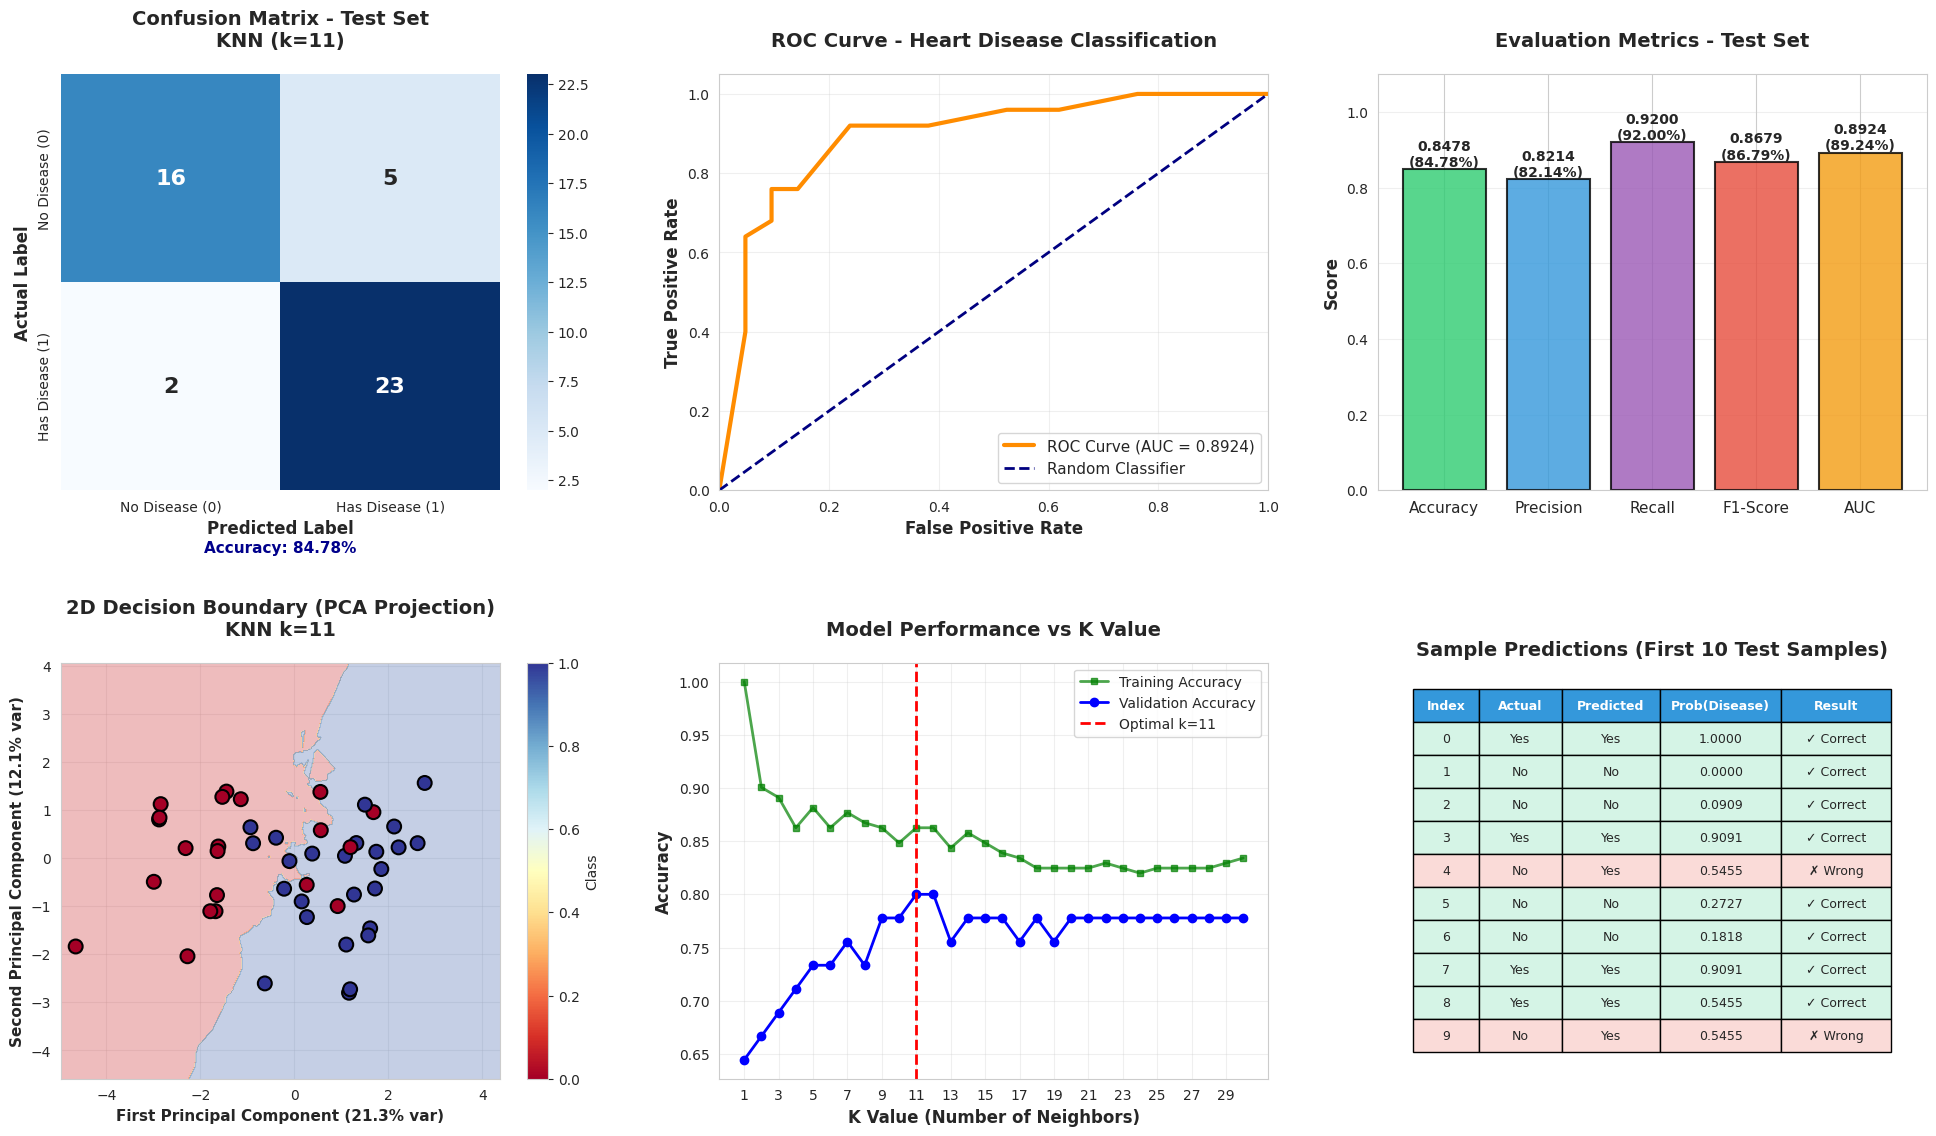


ALL VISUALIZATIONS COMPLETED!


In [8]:
# Step 7: Create All Required Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.decomposition import PCA
import numpy as np

# Set style
sns.set_style("whitegrid")

print("=" * 60)
print("GENERATING ALL VISUALIZATIONS")
print("=" * 60)

# Create main figure
fig = plt.figure(figsize=(20, 12))

# ============================================================
# 1. CONFUSION MATRIX HEATMAP
# ============================================================
print("\n[1/6] Creating Confusion Matrix Heatmap...")
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Disease (0)', 'Has Disease (1)'],
            yticklabels=['No Disease (0)', 'Has Disease (1)'],
            annot_kws={'size': 16, 'weight': 'bold'})

plt.title('Confusion Matrix - Test Set\nKNN (k=11)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

accuracy_text = f'Accuracy: {test_accuracy*100:.2f}%'
plt.text(0.5, -0.15, accuracy_text, ha='center', transform=ax1.transAxes,
         fontsize=11, fontweight='bold', color='darkblue')

# ============================================================
# 2. ROC CURVE
# ============================================================
print("[2/6] Creating ROC Curve...")
ax2 = plt.subplot(2, 3, 2)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=3,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Heart Disease Classification',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

# ============================================================
# 3. EVALUATION METRICS BAR CHART
# ============================================================
print("[3/6] Creating Metrics Bar Chart...")
ax3 = plt.subplot(2, 3, 3)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
scores = [test_accuracy, test_precision, test_recall, test_f1, test_auc]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']

bars = plt.bar(metrics, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for i, (bar, score) in enumerate(zip(bars, scores)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}\n({score*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim([0, 1.1])
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Evaluation Metrics - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', alpha=0.3)

# ============================================================
# 4. 2D DECISION BOUNDARY PLOT (using PCA)
# ============================================================
print("[4/6] Creating 2D Decision Boundary Plot...")
ax4 = plt.subplot(2, 3, 4)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train KNN on 2D data
knn_2d = KNeighborsClassifier(n_neighbors=11, weights='uniform', metric='minkowski')
knn_2d.fit(X_train_pca, y_train)

# Create mesh
h = 0.02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

# Plot test points
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                     c=y_test, cmap='RdYlBu',
                     edgecolors='black', s=100, linewidth=1.5)

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]*100:.1f}% var)',
           fontsize=11, fontweight='bold')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]*100:.1f}% var)',
           fontsize=11, fontweight='bold')
plt.title('2D Decision Boundary (PCA Projection)\nKNN k=11',
          fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='Class', ax=ax4)
plt.grid(True, alpha=0.3)

# ============================================================
# 5. K VALUE COMPARISON
# ============================================================
print("[5/6] Creating K-Value Comparison...")
ax5 = plt.subplot(2, 3, 5)

# Use data from elbow method
k_range = range(1, 31)
train_scores_elbow = []
val_scores_elbow = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores_elbow.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    val_scores_elbow.append(accuracy_score(y_val, knn.predict(X_val_scaled)))

plt.plot(k_range, train_scores_elbow, 'g-s', linewidth=2, markersize=5,
         label='Training Accuracy', alpha=0.7)
plt.plot(k_range, val_scores_elbow, 'b-o', linewidth=2, markersize=6,
         label='Validation Accuracy')
plt.axvline(x=11, color='red', linestyle='--', linewidth=2, label='Optimal k=11')

plt.xlabel('K Value (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Performance vs K Value', fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 31, 2))

# ============================================================
# 6. SAMPLE PREDICTIONS TABLE
# ============================================================
print("[6/6] Creating Sample Predictions Table...")
ax6 = plt.subplot(2, 3, 6)
ax6.axis('tight')
ax6.axis('off')

table_data = []
table_data.append(['Index', 'Actual', 'Predicted', 'Prob(Disease)', 'Result'])

for i in range(min(10, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_test_pred[i]
    prob = y_test_proba[i]
    result = "✓ Correct" if actual == predicted else "✗ Wrong"

    actual_label = "No" if actual == 0 else "Yes"
    pred_label = "No" if predicted == 0 else "Yes"

    table_data.append([f'{i}', actual_label, pred_label, f'{prob:.4f}', result])

table = ax6.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.12, 0.15, 0.18, 0.22, 0.20])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows
for i in range(1, len(table_data)):
    if '✓' in table_data[i][4]:
        for j in range(5):
            table[(i, j)].set_facecolor('#d5f4e6')
    else:
        for j in range(5):
            table[(i, j)].set_facecolor('#fadbd8')

plt.title('Sample Predictions (First 10 Test Samples)',
          fontsize=14, fontweight='bold', pad=20, y=0.95)

# ============================================================
# SAVE AND SHOW
# ============================================================
plt.tight_layout(pad=3.0)
plt.savefig('knn_heart_disease_evaluation.png', dpi=300, bbox_inches='tight')
print("\n✓ All visualizations saved as 'knn_heart_disease_evaluation.png'")
plt.show()

print("\n" + "=" * 60)
print("ALL VISUALIZATIONS COMPLETED!")
print("=" * 60)